# Meta Superintelligence Labs compute model

A Monte Carlo estimate of Meta Superintelligence Labs' (MSL) compute at the
end of 2025, in H100-equivalents (H100e).

MSL compute is built up as a product of three pieces, plus a rented-cloud
top-up:

1. **Total Meta owned H100e** — Nvidia fleet + AMD Instinct fleet, sampled
   independently from the lognormal CIs in the dashboard.
2. **Deployment lag** (operational / owned) — only part of the owned fleet is
   actually online at any moment.
3. **MSL share of operational compute** — the split between frontier AI work
   (MSL training/R&D plus Meta AI inference) and Meta's core-business ML
   (ad/feed recommenders and other production models).
4. **Rented cloud compute** — whatever slice of the CoreWeave / Google /
   Oracle deals was already delivering at year-end, from a spend run-rate
   prior times a rental-price conversion.

The model is simpler than the DeepMind one because Meta's fleet is almost
entirely internal at end-2025: Meta doesn't rent meaningful compute to
external customers, and its own cloud rentals (CoreWeave / Google / Oracle
deals worth $10–20B each, signed Sept–Oct 2025) had mostly not ramped yet.
Owned ≈ used for the core fleet; what may have come online by December is a
small, uncertain **rented cloud** term with a real chance of being zero:

> `MSL H100e = total_owned × deployment_lag × MSL_share + rented_cloud`

Meta's in-house MTIA accelerator is excluded (low volumes through 2025).

**Inputs are lognormal** unless noted — each parameter's low/high bounds are
read as the **90% credible interval** (5th–95th percentile), so the lognormal
median lands near the geometric mean of the two bounds. The exception is the
rented-cloud spend, a zero-inflated lognormal built in section 4.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq
from squigglepy.numbers import K, M

# Shared modules (lab_compute_utils, epoch_data) live at the repo root, one
# level up from notebooks/.
sys.path.insert(0, str(Path('..').resolve()))

N_SAMPLES = 5000
# squigglepy uses its own RNG; np.random.seed has no effect on sq sampling
sq.set_seed(42)


def fmt(x):
    """Format an H100e count for labels (millions or thousands)."""
    if x >= 1e6:
        return f"{x / 1e6:.2f}M"
    return f"{x / 1e3:.0f}k"


def summary(name, samples):
    """Print 5th / median / 95th and mean for a sample array.

    Values below 10 are treated as fractions and shown as decimals; larger
    values are H100e counts and shown in millions/thousands.
    """
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    f = (lambda x: f"{x:.3f}") if np.median(samples) < 10 else fmt
    print(f"{name}")
    print(f"  90% CI : {f(p[5])} – {f(p[95])}")
    print(f"  median : {f(p[50])}")
    print(f"  mean   : {f(np.mean(samples))}")
    return p

## Canonical parameters

The headline priors are loaded from `lab_model_params.csv` — the single source
of truth shared with the other lab notebooks and `frontier_lab_compute_model.py`.
Edit the sheet (leaving a note in its description column) to change a prior.
Sensitivity cells further down build local variants and don't touch it.

In [2]:
from lab_compute_utils import load_lab_params, lab_params_table

PARAMS = load_lab_params()["msl"]
lab_params_table("msl")

,param,dist,low,high,lclip,rclip,units,description,last_updated
0,nvidia_owned,to,1430000.00,2380000.00,NaN,NaN,H100e,"Meta Nvidia fleet, end-2025 sold basis (AI Chi...",7/2/26
1,amd_owned,to,345000.00,612000.00,NaN,NaN,H100e,"Meta AMD Instinct fleet, end-2025 (~20% of tot...",7/2/26
2,deployment_lag,to,0.62,0.90,NaN,NaN,ratio,Operational / owned; 0.5- to 2-quarter lag on ...,7/2/26
3,msl_share,to,0.33,0.80,0.1,0.9,share,MSL (frontier) vs core-business recommender sp...,7/2/26
4,cloud_p_nothing_online,const,0.25,NaN,NaN,NaN,probability,Chance ~no third-party cloud capacity was deli...,7/8/26
5,cloud_spend_run_rate,to,0.50,3.50,NaN,5.0,$B/yr,Meta end-2025 cloud spend run rate if capacity...,7/8/26
6,lag_quarters_2024,to,0.50,2.00,NaN,NaN,quarters,"End-2024 backcast: deployment lag in quarters,...",7/10/26
7,meta_ai_share_2024,to,0.25,0.80,0.1,0.9,share,End-2024 backcast: Meta AI / GenAI (pre-MSL) f...,7/10/26
8,meta_amd_share_2024,to,0.30,0.55,NaN,NaN,share,Meta's share of the all-owner AMD Instinct fle...,7/10/26


## 1. Total Meta owned H100e

Lognormal fits to the dashboard 90% CIs (AI Chip Owners, end-2025, sold
basis). AMD Instinct is roughly 20% of the total. The Nvidia and AMD fleets
are drawn independently. As in the DeepMind model this is a simplified
assumption: there are arguments for correlation (we're generally off about
total Meta H100e) and for anti-correlation (AMD purchases substitute for
Nvidia ones).

Distributions are taken from AI Chip Owners/Sales, with the same caveat that
the dashboard CIs are arguably too narrow.

In [3]:
nvidia_owned = PARAMS["nvidia_owned"]  # median ~1.84M
amd_owned = PARAMS["amd_owned"]        # median ~460k

nvidia_samples = nvidia_owned @ N_SAMPLES
amd_samples = amd_owned @ N_SAMPLES
total_owned = nvidia_samples + amd_samples

summary("Nvidia owned", nvidia_samples)
summary("AMD owned", amd_samples)
summary("Total Meta owned H100e", total_owned);

Nvidia owned
  90% CI : 1.42M – 2.37M
  median : 1.84M
  mean   : 1.86M
AMD owned
  90% CI : 344k – 614k
  median : 458k
  mean   : 467k
Total Meta owned H100e
  90% CI : 1.87M – 2.84M
  median : 2.31M
  mean   : 2.33M


## 2. Deployment lag (operational / owned)

Meta's owned stock grew by ~0.4–0.5M H100e per quarter through 2025
(quarterly medians from the AI Chip Owners data: ~1.42M end-Q2, ~1.83M
end-Q3, ~2.30M end-Q4, up from ~700k at end-2024). Treating the operational
fleet as the sold stock from some quarters earlier: a 0.5-quarter lag
implies an operational/owned ratio of ~0.90, a 1-quarter lag ~0.79, a
2-quarter lag ~0.62. We take the 90% CI as the **0.5- to 2-quarter** range,
i.e. 0.62–0.90. The lognormal median lands around 0.75, which puts the
1-quarter scenario (0.79) inside the central mass rather than out at the
tail.

In [4]:
deployment_lag = PARAMS["deployment_lag"]
deployment_lag_samples = deployment_lag @ N_SAMPLES
operational = total_owned * deployment_lag_samples

summary("Deployment lag", deployment_lag_samples)
summary("Operational H100e", operational);

Deployment lag
  90% CI : 0.621 – 0.906
  median : 0.744
  mean   : 0.751
Operational H100e
  90% CI : 1.31M – 2.29M
  median : 1.72M
  mean   : 1.75M


## 3. MSL share of operational compute

The frontier vs core-business split of Meta's fleet:

- Mid-2025 analyst estimates put **50–60% of Meta's GPUs on recommenders**,
  i.e. a frontier share of 40–50%.
- Meta's Q1-2025 guidance sent the **majority of 2025 capex** to the core
  business (including recommender AI), not generative AI.
- But the frontier share has been climbing fast: the 100k-H100 frontier
  training cluster of late 2024 was only ~15% of Meta's then-fleet (Llama 3
  405B used 16k H100s; Llama 4 Behemoth, 32k), and the formation of MSL in
  mid-2025 and the late-2025 frontier pivot likely tilted allocation further
  toward MSL by year-end.

We center the split at ~50:50 with a deliberately wide band: lognormal
over 0.33–0.8 (median ~0.51), clipped to 0.1–0.9 — the true split is
uncertain but very unlikely to be more lopsided than 90:10 in either
direction. __Like the DeepMind shares,
this is a vibe-sy central estimate and should not be taken literally.__ It
is also sensitive to what counts as MSL (the research org only? all Meta AI
inference? GenAI features inside the ads stack?).

MSL share of operational compute
  90% CI : 0.334 – 0.812
  median : 0.520
  mean   : 0.538


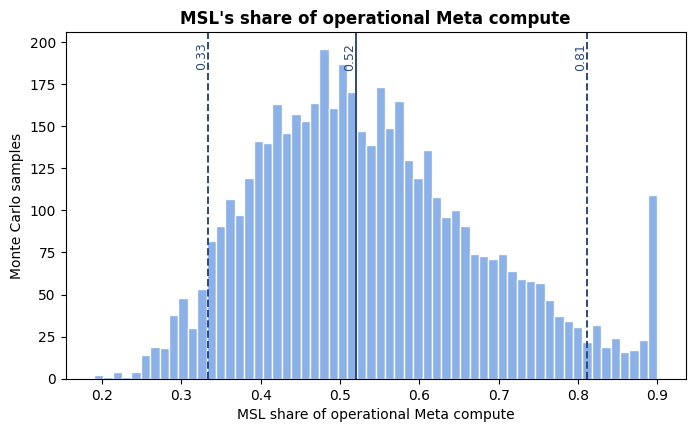

In [5]:
msl_share = PARAMS["msl_share"]
msl_share_samples = msl_share @ N_SAMPLES

p = summary("MSL share of operational compute", msl_share_samples)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(msl_share_samples, bins=60, color="#7FA9E6", alpha=0.9,
        edgecolor="white")
for q, style in [(5, "--"), (50, "-"), (95, "--")]:
    ax.axvline(p[q], color="#2B4A7E", ls=style, lw=1.4)
    ax.text(p[q], ax.get_ylim()[1] * 0.97, f"{p[q]:.2f}", rotation=90,
            va="top", ha="right", fontsize=9, color="#2B4A7E")
ax.set_xlabel("MSL share of operational Meta compute")
ax.set_ylabel("Monte Carlo samples")
ax.set_title("MSL's share of operational Meta compute", weight="bold")
plt.show()

## 4. Rented cloud compute

In September–October 2025 Meta signed large multi-year cloud deals —
CoreWeave ($14B through 2031), Google (~$10B over six years), Oracle (~$20B
reported) — worth roughly $7.5B/yr combined at full run rate. Very little of
that was delivering by December: CoreWeave's disclosures cap Meta's 2025
revenue below $0.5B (under 10% of CoreWeave's ~$5B year) and its Q1-2026 run
rate below ~$0.8B/yr — about a third of that deal's full rate, a quarter
after signing.

The spend rate is therefore a **zero-inflated lognormal**, built from two
sheet rows: a point mass at $0 (the chance nothing was delivering yet) and,
if capacity was flowing, a lognormal run rate hard-capped at the ~$5B/yr
bound the CoreWeave ramp gap implies. Dollars then convert to H100e through
a single **price per H100e-hour**, anchored on the rack-scale Blackwells the
cloud providers are deploying.

In [6]:
HOURS_PER_YEAR = 8760  # rented capacity bills around the clock

# 25% chance nothing was online; otherwise to(0.5, 3.5) capped at $5B/yr.
p_nothing_online = PARAMS["cloud_p_nothing_online"]  # const row -> plain float
cloud_spend = sq.zero_inflated(p_nothing_online, PARAMS["cloud_spend_run_rate"])
cloud_spend_samples = cloud_spend @ N_SAMPLES  # $B/yr

# Rental price per H100e-hour, anchored on SemiAnalysis InferenceX (August
# 2025 pricing surveys, https://inferencex.semianalysis.com/inference):
# GB200 $3.30/GPU-hr and GB300 $3.96/GPU-hr, both
# ~2.5 H100e per GPU, so the GB200–GB300 range gives $1.32–1.58 per
# H100e-hour. Shaded down to a 90% CI of $1.20–1.50: InferenceX quotes 3-year
# rental prices, while Meta's deals run 5–6 years and Meta is a very large
# customer — both should buy a discount.
# - Pricing on very large cloud deals spiked in spring 2026 (e.g. the SpaceX
#   deals), but that repricing postdates Meta's fall-2025 contracts.
price_per_h100e_hour = sq.to(1.20, 1.50)

rented_h100e = (cloud_spend_samples * 1e9
                / ((price_per_h100e_hour @ N_SAMPLES) * HOURS_PER_YEAR))

print(f"P(no rented capacity) = {np.mean(cloud_spend_samples == 0):.0%}\n")
summary("Cloud spend run rate ($B/yr)", cloud_spend_samples)
summary("Rented H100e", rented_h100e);

P(no rented capacity) = 24%

Cloud spend run rate ($B/yr)
  90% CI : 0.000 – 3.256
  median : 1.064
  mean   : 1.194
Rented H100e
  90% CI : 0k – 279k
  median : 91k
  mean   : 102k


Rented capacity is billed as it is delivered, so no deployment-lag haircut
applies. The reporting describes these as AI-infrastructure deals (CNBC on
the Google deal), so the whole term is counted toward MSL rather than split
with the recommender stack.

In [7]:
msl_owned_slice = operational * msl_share_samples
msl_compute = msl_owned_slice + rented_h100e

summary("MSL H100e (owned slice only)", msl_owned_slice)
summary("MSL H100e", msl_compute);

MSL H100e (owned slice only)
  90% CI : 531k – 1.52M
  median : 892k
  mean   : 942k
MSL H100e
  90% CI : 606k – 1.64M
  median : 996k
  mean   : 1.04M


## Monte Carlo summary

The MSL total is the product of three sampled parameters, plus the rented
cloud term:

> `MSL H100e = total_owned × deployment_lag × MSL_share + rented_cloud`

Unlike the DeepMind model there is no blended-fraction step — the share is
sampled directly. Each row below shows one input parameter: the error bar
spans the 90% credible interval, with a dot at the median. The left column
reads out the chain at medians.

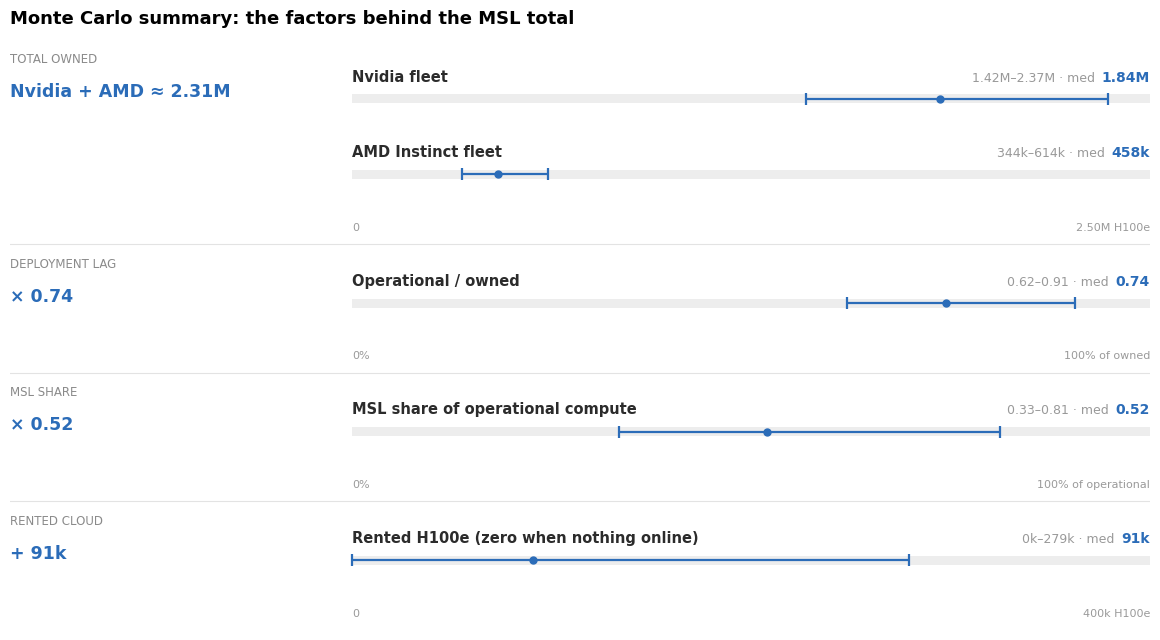

In [8]:
def label_spans(ax, x, y, spans, pad_px=7):
    """Draw text spans left-to-right starting at data-x, each with its own style."""
    for txt, kw in spans:
        t = ax.text(x, y, txt, ha="left", va="bottom", **kw)
        ax.figure.canvas.draw()
        x = ax.transData.inverted().transform(
            (t.get_window_extent().x1 + pad_px, 0))[0]


def label_spans_right(ax, x, y, spans, pad_px=7):
    """Draw text spans (given left-to-right) so they end right-aligned at data-x."""
    for txt, kw in reversed(spans):
        t = ax.text(x, y, txt, ha="right", va="bottom", **kw)
        ax.figure.canvas.draw()
        x = ax.transData.inverted().transform(
            (t.get_window_extent().x0 - pad_px, 0))[0]


owned_scale = 2.5 * M  # a bit above the Nvidia fleet's 95th percentile

sections = [
    dict(kicker="TOTAL OWNED",
         headline=f"Nvidia + AMD ≈ {fmt(np.median(total_owned))}",
         rows=[("Nvidia fleet", nvidia_samples),
               ("AMD Instinct fleet", amd_samples)],
         scale=owned_scale,
         axis_labels=("0", f"{fmt(owned_scale)} H100e")),
    dict(kicker="DEPLOYMENT LAG",
         headline=f"× {np.median(deployment_lag_samples):.2f}",
         rows=[("Operational / owned", deployment_lag_samples)],
         scale=1.0,
         axis_labels=("0%", "100% of owned")),
    dict(kicker="MSL SHARE",
         headline=f"× {np.median(msl_share_samples):.2f}",
         rows=[("MSL share of operational compute", msl_share_samples)],
         scale=1.0,
         axis_labels=("0%", "100% of operational")),
    dict(kicker="RENTED CLOUD",
         headline=f"+ {fmt(np.median(rented_h100e))}",
         rows=[("Rented H100e (zero when nothing online)", rented_h100e)],
         scale=400 * K,
         axis_labels=("0", "400k H100e")),
]

ROW_H, FOOTER_H = 1.0, 0.7
height_units = sum(len(s["rows"]) for s in sections) * ROW_H + FOOTER_H * len(sections)

fig, ax = plt.subplots(figsize=(12, 0.78 * height_units + 0.7))
fig.subplots_adjust(left=0.03, right=0.98, top=0.9, bottom=0.03)
ax.set_xlim(0, 1)
ax.set_ylim(0, height_units)
ax.axis("off")

BAR_X0, BAR_X1 = 0.30, 1.00
y = height_units
for i, sec in enumerate(sections):
    fr = fmt if sec["scale"] > 10 else (lambda v: f"{v:.2f}")
    # left column: section kicker plus the factor it contributes at medians
    ax.text(0, y - 0.34, sec["kicker"], fontsize=8.5, color="#8a8a8a",
            va="bottom")
    ax.text(0, y - 0.80, sec["headline"], fontsize=12.5, fontweight="bold",
            color="#2B6CB8", va="bottom")
    for name, samples in sec["rows"]:
        y -= ROW_H
        lo, med, hi = np.percentile(samples, [5, 50, 95])
        to_x = lambda v: BAR_X0 + (v / sec["scale"]) * (BAR_X1 - BAR_X0)
        ax.text(BAR_X0, y + 0.42, name, fontsize=10.5, fontweight=600,
                color="#2b2b2b", va="bottom")
        label_spans_right(ax, BAR_X1, y + 0.42, [
            (f"{fr(lo)}–{fr(hi)} · med", dict(fontsize=9, color="#999999")),
            (fr(med), dict(fontsize=10, fontweight="bold", color="#2B6CB8")),
        ])
        # full-axis track, then the 90% CI as an error bar with a median dot
        ax.barh(y + 0.22, BAR_X1 - BAR_X0, left=BAR_X0, height=0.12,
                color="#EDEDED", zorder=1)
        ax.errorbar(to_x(med), y + 0.22,
                    xerr=[[to_x(med) - to_x(lo)], [to_x(hi) - to_x(med)]],
                    fmt="o", ms=5, color="#2B6CB8", ecolor="#2B6CB8",
                    elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
    # section footer (axis extent hints) and divider
    y -= FOOTER_H
    ax.text(BAR_X0, y + 0.16, sec["axis_labels"][0], fontsize=8,
            color="#9a9a9a", va="bottom")
    ax.text(BAR_X1, y + 0.16, sec["axis_labels"][1], fontsize=8,
            color="#9a9a9a", va="bottom", ha="right")
    if i < len(sections) - 1:
        ax.axhline(y, color="#e3e3e3", lw=0.8)

ax.set_title("Monte Carlo summary: the factors behind the MSL total",
             loc="left", fontsize=13, weight="bold", pad=12)
plt.show()

## Final visualization

Three magnitudes on one axis: owned and operational run to their medians
(CIs in the labels), while the MSL bar runs to its median with an error bar
spanning its 90% interval.

The median lands a bit under 1M H100e — consistent with the bottom line in
the modeling summary (MSL ≈ half of Meta's ~2.3M owned, less after
deployment lag, plus a small rented-cloud top-up). Even the 95th percentile
sits below OpenAI's central ~1.7M estimate, supporting the conclusion that
MSL likely had less compute than OpenAI at end-2025.

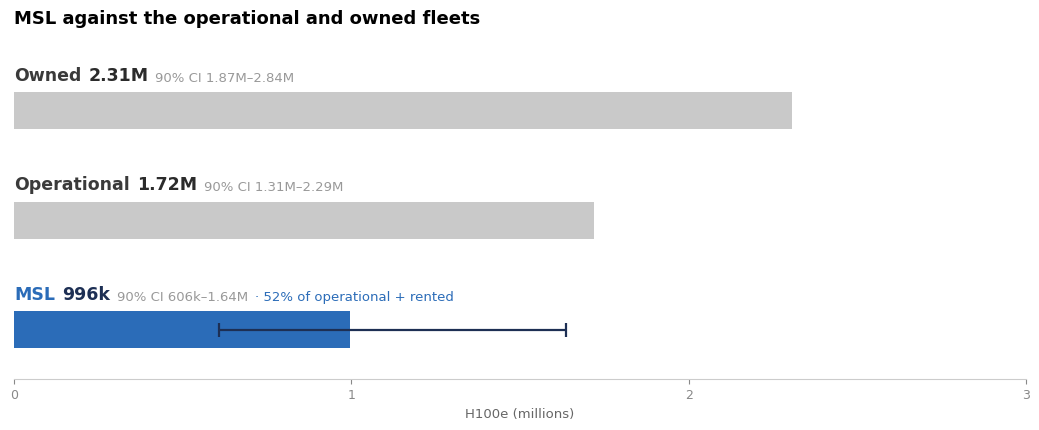

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.6))
fig.subplots_adjust(left=0.05, right=0.97, top=0.86, bottom=0.13)
ax.set_xlim(0, 3)
ax.set_ylim(-0.45, 2.62)

bar_h = 0.34
share_of_op = np.median(msl_share_samples)

for name, samples, y in [("Owned", total_owned, 2),
                         ("Operational", operational, 1),
                         ("MSL", msl_compute, 0)]:
    lo, med, hi = np.percentile(samples, [5, 50, 95])
    is_lab = name == "MSL"
    spans = [
        (name, dict(fontsize=12.5, fontweight="bold",
                    color="#2B6CB8" if is_lab else "#3a3a3a")),
        (fmt(med), dict(fontsize=12.5, fontweight="bold",
                        color="#1d2f54" if is_lab else "#2b2b2b")),
        (f"90% CI {fmt(lo)}–{fmt(hi)}", dict(fontsize=9.5, color="#999999")),
    ]
    if is_lab:
        # bar to the median, error bar spanning the 90% CI
        ax.barh(y, med / 1e6, height=bar_h, color="#2B6CB8")
        ax.errorbar(med / 1e6, y,
                    xerr=[[(med - lo) / 1e6], [(hi - med) / 1e6]],
                    fmt="none", ecolor="#1d2f54", elinewidth=1.6,
                    capsize=5, capthick=1.6, zorder=3)
        spans.append((f"· {share_of_op:.0%} of operational + rented",
                      dict(fontsize=9.5, color="#2B6CB8")))
    else:
        ax.barh(y, med / 1e6, height=bar_h, color="#C9C9C9")
    label_spans(ax, 0, y + 0.24, spans)

for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.set_yticks([])
ax.set_xticks(range(0, 4))
ax.tick_params(axis="x", colors="#888888", labelsize=9)
ax.set_xlabel("H100e (millions)", color="#666666", fontsize=9.5)
ax.set_title("MSL against the operational and owned fleets",
             loc="left", fontsize=13, weight="bold", pad=14)
plt.show()

## MSL H100e distribution

The full Monte Carlo distribution behind the headline number — the bar chart
above collapses this to a median and 90% interval. The long right tail is the
signature of a product of uncertain factors (owned fleet × deployment lag ×
MSL share) plus the zero-inflated rented-cloud top-up: the median sits well
below the mean.

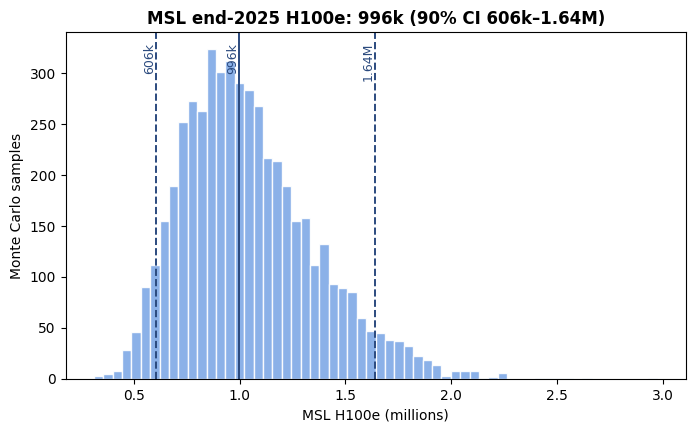

In [10]:
msl_p = sq.get_percentiles(msl_compute, percentiles=[5, 50, 95])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(msl_compute / 1e6, bins=60, color="#7FA9E6", alpha=0.9,
        edgecolor="white")
for q, style in [(5, "--"), (50, "-"), (95, "--")]:
    ax.axvline(msl_p[q] / 1e6, color="#2B4A7E", ls=style, lw=1.4)
    ax.text(msl_p[q] / 1e6, ax.get_ylim()[1] * 0.97, fmt(msl_p[q]), rotation=90,
            va="top", ha="right", fontsize=9, color="#2B4A7E")
ax.set_xlabel("MSL H100e (millions)")
ax.set_ylabel("Monte Carlo samples")
ax.set_title(f"MSL end-2025 H100e: {fmt(msl_p[50])} "
             f"(90% CI {fmt(msl_p[5])}–{fmt(msl_p[95])})", weight="bold")
plt.show()

## Sensitivity check: narrowing and widening the MSL-share uncertainty

The baseline 0.33–0.8 CI is deliberately wide. A tighter reading — taking
the mid-2025 analyst split roughly at face value — would be something like
0.40–0.60; and there are also reasons to go wider still: how far the
late-2025 pivot had actually shifted allocation by December, and what
counts as MSL at all. Here we re-run the model across that ladder — from
the tight analyst-anchored band out to the 0.1–0.9 hard bounds — reusing
the same owned-fleet, deployment-lag, and rented-cloud draws so the only
thing that changes is the share spread:

- **0.40–0.60** — tight: the analyst split at face value.
- **0.33–0.80** — baseline (the canonical prior in the sheet).
- **0.27–0.90** — wider; the top of the CI touches the 0.9 hard bound.
- **0.10–0.90, uniform** — the limit case: any split between the 10:90 and
  90:10 hard bounds is equally likely. (A lognormal this wide centered near
  0.5 isn't possible — its geometric median would slide down to 0.3 — so the
  limit case switches to a uniform.)

Each bar runs to the median of the resulting MSL distribution, with an
error bar spanning the 90% interval. Because every row centers near ~50:50,
the median barely moves — the band width mainly stretches the tails.
With the rented-cloud term included, the widest (uniform) case's 95th
percentile now just reaches OpenAI's central ~1.7M; the lognormal rows
stay below it.

                    share CI       5th    median      95th   90% CI width
           0.40–0.60 (tight)      663k      939k     1.33M           671k
        0.33–0.80 (baseline)      606k      996k     1.64M          1.03M
           0.27–0.90 (wider)      518k      946k     1.67M          1.15M
         0.10–0.90 (uniform)      319k      952k     1.73M          1.41M

Medians stay pinned near 939k throughout; the widest case grows the 90% CI width +110% and its 95th percentile reaches 1.73M.


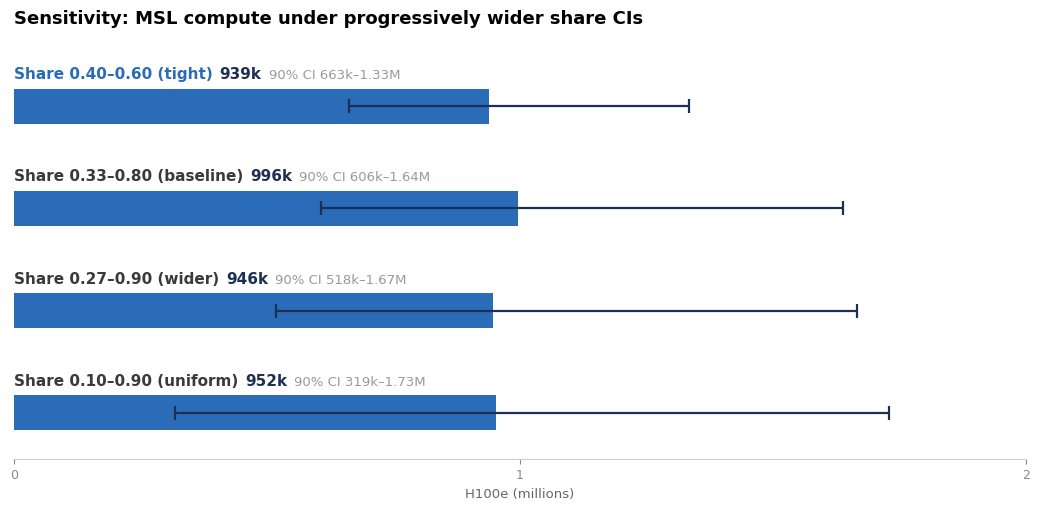

In [11]:
# Share CIs from tight to maximal. The lognormal rows keep their geometric
# median near ~0.5; the uniform row is the maximal-uncertainty limit between
# the hard bounds. Owned and lag draws are reused so only the share changes.
share_scenarios = [
    ("0.40–0.60 (tight)",
     sq.to(0.4, 0.6, lclip=0.1, rclip=0.9) @ N_SAMPLES),
    ("0.33–0.80 (baseline)", msl_share_samples),
    ("0.27–0.90 (wider)",
     sq.to(0.27, 0.90, lclip=0.1, rclip=0.9) @ N_SAMPLES),
    ("0.10–0.90 (uniform)", sq.uniform(0.1, 0.9) @ N_SAMPLES),
]

rows = []
print(f"{'share CI':>28}  {'5th':>8}  {'median':>8}  {'95th':>8}  {'90% CI width':>13}")
for label, share_samples in share_scenarios:
    pc = sq.get_percentiles(operational * share_samples + rented_h100e,
                            percentiles=[5, 50, 95])
    rows.append((label, pc[5], pc[50], pc[95]))
    print(f"{label:>28}  {fmt(pc[5]):>8}  {fmt(pc[50]):>8}  {fmt(pc[95]):>8}  "
          f"{fmt(pc[95] - pc[5]):>13}")

base_width = rows[0][3] - rows[0][1]
widest = rows[-1]
print(f"\nMedians stay pinned near {fmt(rows[0][2])} throughout; the widest case "
      f"grows the 90% CI width {(widest[3] - widest[1]) / base_width - 1:+.0%} "
      f"and its 95th percentile reaches {fmt(widest[3])}.")

fig, ax = plt.subplots(figsize=(11, 5.4))
fig.subplots_adjust(left=0.05, right=0.97, top=0.88, bottom=0.11)
ax.set_xlim(0, 2)
ax.set_ylim(-0.45, len(rows) - 1 + 0.62)

bar_h = 0.34
for i, (label, lo, med, hi) in enumerate(rows):
    y = len(rows) - 1 - i
    # same encoding as the fleet chart: bar to the median, error bar across
    # the 90% interval
    ax.barh(y, med / 1e6, height=bar_h, color="#2B6CB8")
    ax.errorbar(med / 1e6, y, xerr=[[(med - lo) / 1e6], [(hi - med) / 1e6]],
                fmt="none", ecolor="#1d2f54", elinewidth=1.6, capsize=5,
                capthick=1.6, zorder=3)
    label_spans(ax, 0, y + 0.24, [
        (f"Share {label}", dict(fontsize=11, fontweight="bold",
                                color="#2B6CB8" if i == 0 else "#3a3a3a")),
        (fmt(med), dict(fontsize=11, fontweight="bold", color="#1d2f54")),
        (f"90% CI {fmt(lo)}–{fmt(hi)}", dict(fontsize=9.5, color="#999999")),
    ])

for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.set_yticks([])
ax.set_xticks(range(0, 3))
ax.tick_params(axis="x", colors="#888888", labelsize=9)
ax.set_xlabel("H100e (millions)", color="#666666", fontsize=9.5)
ax.set_title("Sensitivity: MSL compute under progressively wider share CIs",
             loc="left", fontsize=13, weight="bold", pad=14)
plt.show()

## Sensitivity check: discrete deployment-lag scenarios

The base case folds deployment lag into one lognormal (0.5–2 quarters as the
90% CI). Reference points from CoreWeave suggest installs took ~3 months in
early 2025 and "within weeks" by late 2025, but Meta's own ramp could be
slower (power constraints, the Hyperion/Prometheus builds). Here we instead
**fix** the lag at discrete scenarios from 0 to 3 quarters — mapping each
lag to an operational/owned ratio via Meta's quarterly stock trajectory,
interpolating between quarter ends for the half-quarter steps — and reuse
the same owned-fleet and share draws so only the lag changes. The modeling
summary's default is a 1-quarter lag.

lag (q)  ratio       5th    median      95th
    0.0   1.00      813k     1.30M     2.07M
    0.5   0.90      737k     1.18M     1.88M
    1.0   0.79      654k     1.05M     1.66M
    1.5   0.70      586k      943k     1.49M
    2.0   0.62      525k      846k     1.34M
    3.0   0.48      418k      677k     1.08M

Default 1-quarter lag: median 1.05M, 90% CI 654k – 1.66M.
Across 0–3 quarters the median spans 677k – 1.30M.


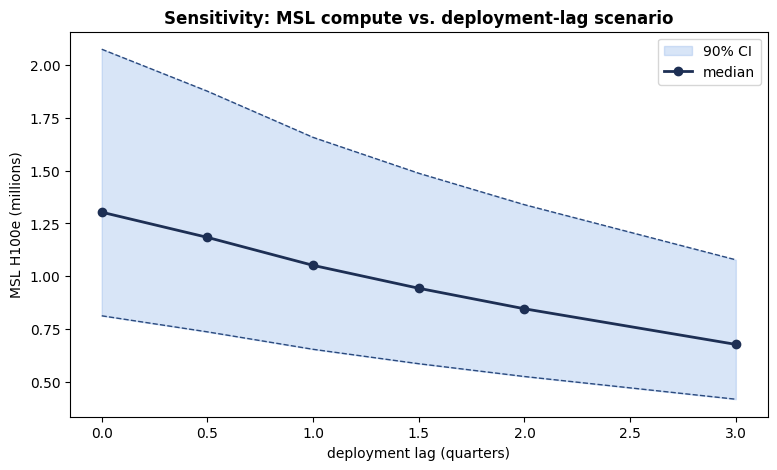

In [12]:
# Lag (quarters) -> operational/owned ratio, read off Meta's quarterly stocks
# (~2.30M end-Q4, ~1.83M end-Q3, ~1.42M end-Q2, ~1.10M end-Q1 2025).
lag_scenarios = [
    (0.0, 1.00),
    (0.5, 0.90),
    (1.0, 0.79),
    (1.5, 0.70),
    (2.0, 0.62),
    (3.0, 0.48),
]

rows = []
for lag_q, ratio in lag_scenarios:
    msl = total_owned * ratio * msl_share_samples + rented_h100e
    pc = sq.get_percentiles(msl, percentiles=[5, 50, 95])
    rows.append((lag_q, ratio, pc[5], pc[50], pc[95]))

print(f"{'lag (q)':>7}  {'ratio':>5}  {'5th':>8}  {'median':>8}  {'95th':>8}")
for lag_q, ratio, lo, med, hi in rows:
    print(f"{lag_q:>7.1f}  {ratio:>5.2f}  {fmt(lo):>8}  {fmt(med):>8}  {fmt(hi):>8}")

one_q = next(r for r in rows if r[0] == 1.0)
print(f"\nDefault 1-quarter lag: median {fmt(one_q[3])}, "
      f"90% CI {fmt(one_q[2])} – {fmt(one_q[4])}.")
print(f"Across 0–3 quarters the median spans "
      f"{fmt(rows[-1][3])} – {fmt(rows[0][3])}.")

lags = [r[0] for r in rows]
los = np.array([r[2] for r in rows]) / 1e6
meds = np.array([r[3] for r in rows]) / 1e6
his = np.array([r[4] for r in rows]) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(lags, los, his, color="#7FA9E6", alpha=0.30, label="90% CI")
ax.plot(lags, his, "--", color="#2B4A7E", lw=1)
ax.plot(lags, los, "--", color="#2B4A7E", lw=1)
ax.plot(lags, meds, "o-", color="#1d2f54", lw=2, label="median")
ax.set_xlabel("deployment lag (quarters)")
ax.set_ylabel("MSL H100e (millions)")
ax.set_title("Sensitivity: MSL compute vs. deployment-lag scenario",
             weight="bold")
ax.legend()
plt.show()